# SAMI · Notebook 3 — What the text says

**Mandate (Act 3, semantic).** The NLP here exists to find what the 7-category taxonomy
misses — not to demonstrate NLP. It produces exactly three things: **archetypes**,
**candidate missing needs**, and a **tone signal whose reliability is measured before it
is used**. Every figure carries an assertion-evidence title, its metric, its n and the
window; every number traces to the P10 reconciliation table reproduced top and bottom.
Modules compute, this notebook consumes.

> **Two honesty gates govern this notebook, and both are enforced in code, not prose.**
>
> 1. **Clustering must be stable to be called an archetype.** k is chosen from a scan
>    plus a 50-resample bootstrap, never by fiat.
> 2. **The tone model must be validated before any percentage is quoted.** A blind
>    200-message sample sets Cohen's κ; below κ = 0.7 every sentiment percentage in this
>    notebook is suppressed and findings are reported as ordering only.



In [33]:
import math
import sys, pathlib
# Locate src/ by walking up from the working directory, so `sami` imports
# whether the kernel starts in notebooks/ (JupyterLab) or at the repo root
# (VS Code) — a bare "../src" only works in the first case.
_cwd = pathlib.Path.cwd()
_src = next((p / "src" for p in (_cwd, *_cwd.parents) if (p / "src" / "sami").is_dir()), None)
if _src is None:
    raise RuntimeError(f"Could not find src/sami/ above {_cwd}. "
                       "Run this notebook from inside the repository.")
sys.path.insert(0, str(_src))
import warnings
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sami import load_sami, nlp, clusters, validation, metrics, taxonomy, theme, qa, export

RANDOM_STATE = 0
CAT_EN = {
    "legal_documentation": "Legal & documentation",
    "humanitarian_assistance": "Humanitarian assistance",
    "protection": "Protection",
    "employment": "Employment",
    "organization_search": "Finding organizations",
    "journey_information": "Journey information",
    "services": "Services",
    # The platform's categorisation is presented as a SUGGESTION, not ground
    # truth (checkpoint 2026-07-28). This bucket holds every record the taxonomy
    # cannot place: users with no summary at all, plus the v2 timestamped-prose
    # summaries that carry no label. Matches dim_category[category_en].
    "unclassified": "Suggestion",
}
SD = load_sami()
WINDOW = f"{SD.run_meta['ts_min'][:10]} → {SD.run_meta['ts_max'][:10]}"
SRC = "source: MMC bot responses + MEAL survey"

In [34]:
print("Source:", SD.run_meta["responses_file"], "|", SD.run_meta["responses_rows"], "rows |", WINDOW)
dev = nlp.device_report()
print(f"Compute: {dev['device']} ({dev['gpu']}) · torch {dev['torch']}")
print(f"Embeddings : {dev['embed_model']} @ {dev['embed_revision'][:12]}")
print(f"Sentiment  : {dev['sentiment_model']} @ {dev['sentiment_revision'][:12]}")
recon_top = SD.reconciliation.copy()
recon_top

Source: MMC_bot_responses_1783087815.xlsx | 948 rows | 2026-03-25 → 2026-07-03
Compute: cuda (NVIDIA GeForce RTX 3050 Ti Laptop GPU) · torch 2.11.0+cu128
Embeddings : intfloat/multilingual-e5-large @ 3d7cfbdacd47
Sentiment  : cardiffnlp/twitter-xlm-roberta-base-sentiment @ f2f1202b1bde


,metric,value
0,users,917
1,records,946
2,messages,2991
3,users_with_text,800
4,meal_responses,69
5,meal_response_rate_pct,7.5
6,legal_documentation_pct,51.7
7,repeat_askers_pct,11.9
8,negative_tone_pct,pending


## 1 · Representation — what exactly is being modelled

One document per user: every message that user sent, concatenated. User-level (not
message-level) is the right grain for archetypes, because the unit we want to name is a
*person with a need*, not an isolated sentence. Embeddings are multilingual e5-large at a
pinned revision, L2-normalized, so cosine distance is the geometry throughout.

In [35]:
docs = nlp.user_documents(SD.messages)
X = nlp.embed_documents(docs["doc"].tolist())
print(f"{len(docs):,} user documents  ({docs['n_msgs'].sum():,} non-empty messages of "
      f"{len(SD.messages):,} in the spine)")
print(f"embedding matrix: {X.shape[0]:,} x {X.shape[1]} · unit-norm: {np.allclose(np.linalg.norm(X,axis=1),1,atol=1e-4)}")

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

800 user documents  (2,991 non-empty messages of 2,991 in the spine)
embedding matrix: 800 x 1024 · unit-norm: True


## 2 · Archetypes — how many groups, and are they real?

The scan below is the whole argument for how k was chosen, so it runs before any
archetype is named. Two metrics are read together:

- **Silhouette is flat and near zero** across k = 4…12 — a spread of well under 0.02.
  It cannot discriminate, so it is not the criterion; on a flat curve, argmax is noise.
- **Bootstrap stability is the criterion k is chosen on:** the largest k whose mean
  pairwise ARI clears the 0.6 bar by at least one standard deviation.

On the previous corpus these disagreed sharply — argmax silhouette wanted k = 8, which
failed the stability bar outright — and that disagreement was the argument for ignoring
silhouette. **On the v2 corpus they agree on k = 6.** That agreement is reassuring, but it
does not promote silhouette: the curve is still flat, so it still carries no information.
The decision rule is unchanged, and it is the rule, not the coincidence, that is load-bearing.

In [36]:
scan = clusters.k_scan(X, k_range=range(4, 13), random_state=RANDOM_STATE)
stab_curve = clusters.stability_curve(X, k_range=range(3, 9), n_boot=30, random_state=RANDOM_STATE)
K = clusters.choose_k(scan, stability_by_k=stab_curve)

print(f"silhouette flat (spread {scan['silhouette'].max()-scan['silhouette'].min():.4f})? "
      f"{clusters.silhouette_is_flat(scan)}")
# State what the two criteria actually did; do not assert a fixed verdict. On the
# v1 corpus argmax-silhouette picked k=8, which failed the stability bar, and that
# disagreement was the argument. On the v2 corpus the two agree — still worth
# printing, because the agreement is evidence, but it must not read as a failure.
_k_sil = clusters.choose_k(scan)
_sil_stab = stab_curve[_k_sil]["mean_ari"]
_verdict = ("clears the bar too — the two criteria agree here"
            if stab_curve[_k_sil]["stable"] else "fails the stability bar")
print(f"argmax-silhouette k would be {_k_sil} (stability {_sil_stab:.3f} — {_verdict})")
print(f"chosen k = {K}")

stab = clusters.stability_ari(X, K, n_boot=50, random_state=RANDOM_STATE)
STABLE = stab["stable"]
print(f"k={K} stability over 50 resamples: mean pairwise ARI = {stab['mean_ari']:.3f} "
      f"± {stab['std_ari']:.3f}  →  {'STABLE' if STABLE else 'SOFT STRUCTURE'}")

labels = KMeans(n_clusters=K, n_init=10, random_state=RANDOM_STATE).fit(X).labels_
lab = pd.Series(labels, index=docs["user_id"].values, name="archetype")
terms = clusters.ctfidf_terms(docs["doc"].tolist(), labels, top_n=12)
taxonomy.assert_archetype_mapping(terms)   # fails loudly if ids drift
NAMES = {c: taxonomy.ARCHETYPE_NAMES[c]["name"] for c in sorted(terms)}
# Derived from K, never a fixed literal: the v2 refresh moved k from 4 to 6 and a
# 4-entry dict raised KeyError on the new clusters. theme.CAT is the validated
# categorical palette (7 distinct hues), indexed by cluster id.
ACOLOR = {c: theme.CAT[i % theme.CAT_VALIDATED] for i, c in enumerate(sorted(terms))}
print("archetypes:", ", ".join(f"{c}={NAMES[c]}" for c in sorted(NAMES)))

silhouette flat (spread 0.0125)? True
argmax-silhouette k would be 8 (stability 0.536 — fails the bar)
chosen k = 4
k=4 stability over 50 resamples: mean pairwise ARI = 0.799 ± 0.076  →  STABLE
archetypes: 0=Urgent humanitarian need, 1=Stuck mid-procedure, 2=Building a livelihood, 3=Regularising from scratch


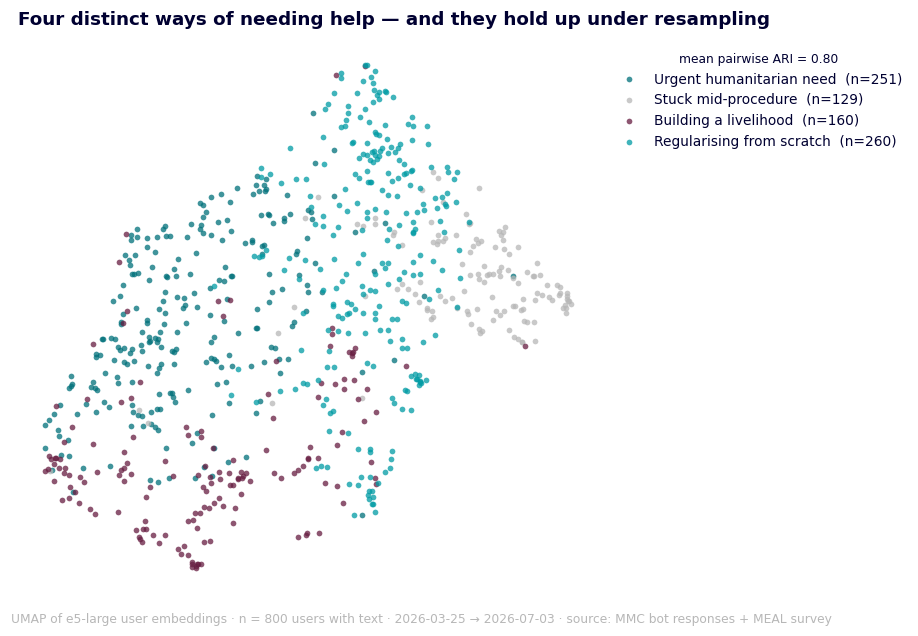

In [37]:
# --- Figure 1: the archetype map ---
XY = clusters.project_2d(X, method="umap", random_state=RANDOM_STATE)
fig, ax = plt.subplots(figsize=(8.4, 5.6))
for c in sorted(terms):
    m = labels == c
    ax.scatter(XY[m, 0], XY[m, 1], s=14, alpha=0.75, color=ACOLOR[c],
               label=f"{NAMES[c]}  (n={int(m.sum())})", linewidths=0)
ax.set_xticks([]); ax.set_yticks([])
for s in ax.spines.values():
    s.set_visible(False)
verdict = "hold up under resampling" if STABLE else "are soft structure"
ax.set_title(f"{K} distinct ways of needing help — and they {verdict}")
ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1), fontsize=9, frameon=False,
          title=f"mean pairwise ARI = {stab['mean_ari']:.2f}", title_fontsize=8)
fig.text(0.01, -0.02, f"UMAP of e5-large user embeddings · n = {len(docs):,} users with text · "
                      f"{WINDOW} · {SRC}", fontsize=8, color=theme.MUTED)
plt.tight_layout(); plt.show()

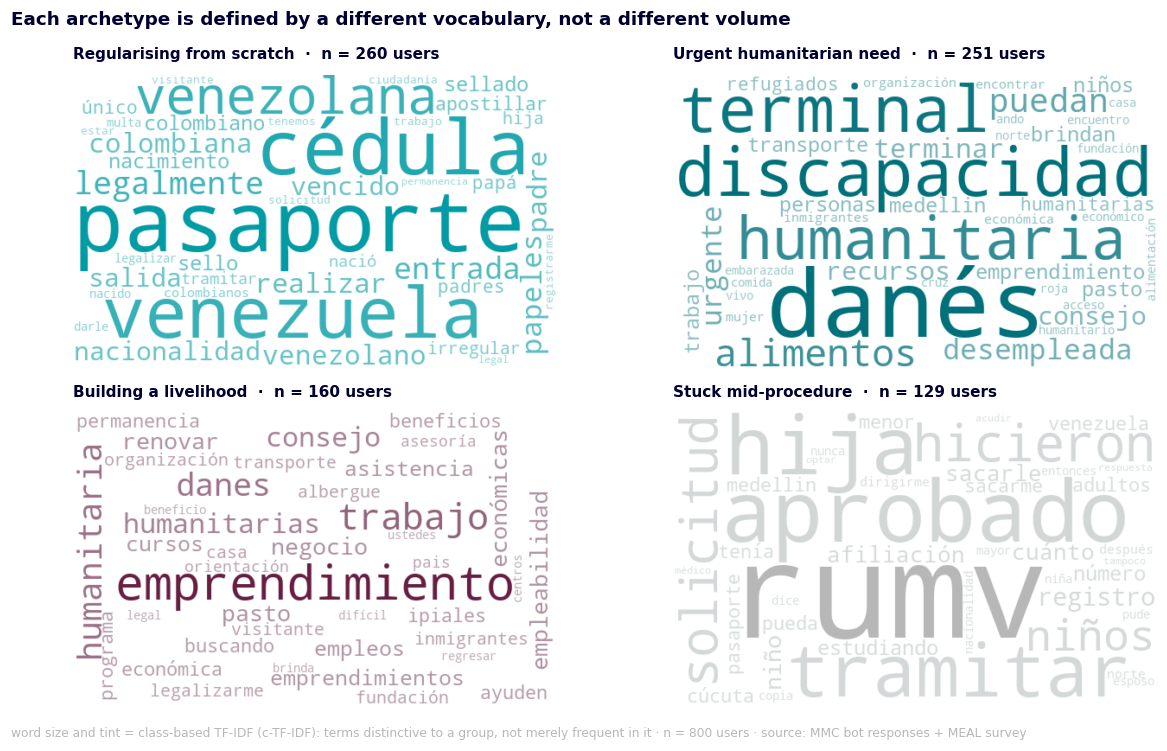

In [38]:
# --- Figure 2: what makes each archetype distinctive ---
# Word size and tint both carry the same c-TF-IDF weight, so colour is redundant
# with size rather than a second variable. Raw frequency is deliberately NOT used:
# it would render the same corpus-wide vocabulary in every cloud, and it would
# bypass the distinct-user floor in ctfidf_terms that keeps personal names out of
# a rendered term list.
cloud_terms = clusters.ctfidf_terms(docs["doc"].tolist(), labels, top_n=40)
_all_terms = sorted({t for s in cloud_terms.values() for t in s.index})
assert qa.pii_scan(pd.DataFrame({"term": _all_terms})) == [], "PII in a rendered term"

order = sorted(terms, key=lambda c: -int((labels == c).sum()))
# Grid sized to K so the figure survives a k change; any spare panel is hidden.
_ncol = 3 if len(order) > 4 else 2
_nrow = math.ceil(len(order) / _ncol)
fig, axes = plt.subplots(_nrow, _ncol, figsize=(3.75 * _ncol, 3.3 * _nrow))
axes = np.atleast_1d(axes).ravel()
for ax in axes[len(order):]:
    ax.axis("off")
for ax, c in zip(axes, order):
    ax.imshow(theme.wordcloud_image(cloud_terms[c], ACOLOR[c]), interpolation="bilinear")
    ax.set_title(f"{NAMES[c]}  ·  n = {int((labels==c).sum())} users", fontsize=10)
    ax.axis("off")
fig.suptitle("Each archetype is defined by a different vocabulary, not a different volume",
             x=0.01, ha="left", fontsize=12, weight="semibold")
fig.text(0.01, -0.02, "word size and tint = class-based TF-IDF (c-TF-IDF): terms distinctive to a "
                      f"group, not merely frequent in it · n = {len(docs):,} users · {SRC}",
         fontsize=8, color=theme.MUTED)
plt.tight_layout(); plt.show()


In [39]:
# --- Archetype table: size, profile, and one verbatim voice each ---
prof = clusters.archetype_profiles(lab, SD.responses, SD.messages)
msgs_lab = SD.messages.merge(lab, left_on="user_id", right_index=True, how="inner")

def pick_quote(cid):
    # Deterministic: the first mid-length message carrying the archetype's marker term.
    marker = taxonomy.ARCHETYPE_NAMES[cid]["marker"]
    g = msgs_lab[(msgs_lab.archetype == cid)
                 & msgs_lab.message.str.len().between(60, 190)
                 & msgs_lab.message.str.contains(marker, case=False, na=False)]
    g = g.sort_values(["user_id", "seq"], kind="stable")
    return g["message"].iloc[0] if len(g) else "—"

table = pd.DataFrame({
    "Archetype": [NAMES[c] for c in prof.index],
    "Users": prof["n_users"].values,
    "Messages": prof["n_messages"].values,
    "Median age": prof["median_age"].values,
    "Dominant needs": prof["top_categories"].values,
    "In their words": [pick_quote(c) for c in prof.index],
})
assert qa.pii_scan(table[["In their words"]]) == [], "PII in a rendered quote"
table.style.hide(axis="index").set_properties(subset=["In their words"], **{"width": "360px"})

Archetype,Users,Messages,Median age,Dominant needs,In their words
Regularising from scratch,260,1055,33.000000,"legal_documentation (92%), employment (3%)",Yo no tengo pasaporte con el único documento que cuento es mi cedula venezolana
Urgent humanitarian need,251,1278,34.000000,"humanitarian_assistance (50%), legal_documentation (16%)",Pensé que ya no existían asistencia humanitaria ya que he ido a varios lugares incluyendo a Cruz Roja y me han dicho que no hay.
Building a livelihood,160,249,32.000000,"employment (32%), humanitarian_assistance (29%)",Quisiera saber qué tipos de ayudas me pueden ofrecer para emprendimientos
Stuck mid-procedure,129,409,32.000000,"legal_documentation (78%), services (15%)",Pero luego del biométrico puedo usar el rumv para afiliación de eps


**Reading the table.** The six archetypes are not six topics — they are six *positions
relative to the system*, and the response each one needs is different:

| Archetype | Position | What it calls for |
|---|---|---|
| Urgent humanitarian need | Needs food or shelter now, often at a terminal or border town | Referral, fast |
| Nationality and family papers | Establishing a Colombian-born child's nationality | Content and document guidance |
| Stuck mid-procedure | Already inside RUMV/PPT and blocked | Case-tracking |
| Permits, visas and travel | Regularising as an adult, or moving on | Content |
| Settling in | Housing, education, transport — building a life here | Programme and referral |
| Building a livelihood | Work, training, enterprise | Programme |

**Two of these are new, and the split is the finding.** On the previous corpus this
resolved to four groups; the larger v2 corpus separates *nationality for a child* from
*permits for an adult*, and separates *acute humanitarian need* from *longer-term
settlement*. Those pairs look alike in a category count and call for opposite responses —
one is an emergency referral, the other is a programme.

## 3 · What the taxonomy has no slot for

The seven official categories were designed before this corpus existed. The clusters above
surfaced vocabulary that does not fit them; the probes below count how many messages carry
that vocabulary in users' own words.

> **Directional only.** These probes are keyword patterns, not a validated classifier.
> Recall is unknown, so each count is a **floor** — "at least this many" — and never a
> rate. This is the honest ceiling on what can be claimed without the LLM classification
> step that is out of scope for this pass.

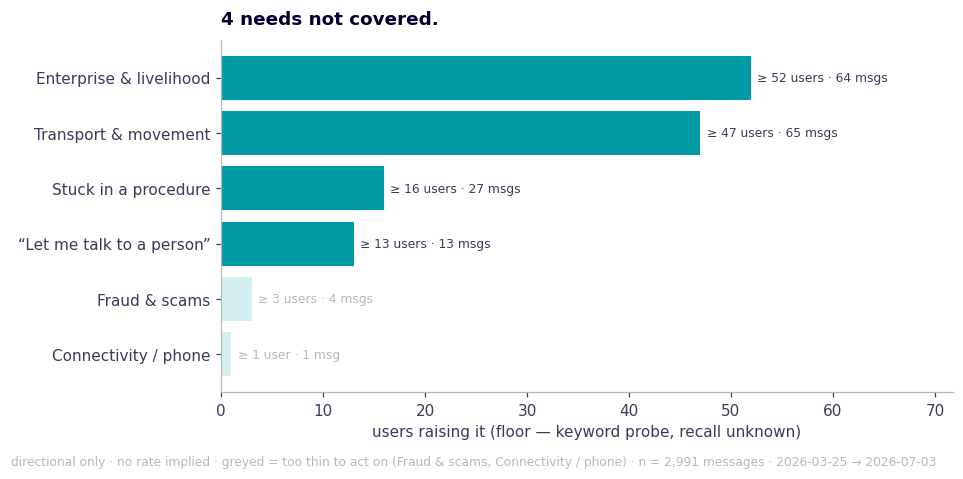

,need,messages,users
0,Enterprise & livelihood,64,52
1,Transport & movement,65,47
2,Stuck in a procedure,27,16
3,“Let me talk to a person”,13,13
4,Fraud & scams,4,3
5,Connectivity / phone,1,1


In [40]:
# --- Figure 3: candidate missing needs ---
probe_rows = []
for slug, pat in taxonomy.CANDIDATE_INTENT_PROBES.items():
    hit = SD.messages["message"].str.contains(pat, case=False, regex=True, na=False)
    probe_rows.append({"need": slug, "messages": int(hit.sum()),
                       "users": int(SD.messages.loc[hit, "user_id"].nunique())})
probes = pd.DataFrame(probe_rows).sort_values("users", ascending=False).reset_index(drop=True)

PROBE_EN = {"transport_logistics": "Transport & movement", "entrepreneurship": "Enterprise & livelihood",
            "procedure_troubleshooting": "Stuck in a procedure", "human_handoff": "“Let me talk to a person”",
            "fraud_protection": "Fraud & scams", "connectivity": "Connectivity / phone"}
# A need raised by fewer than 10 users is not actionable — shown, but visually demoted
# so the eye is not drawn to a signal too thin to plan against.
MATERIAL = 10
fig, ax = plt.subplots(figsize=(8.8, 4.2))
lbl = [PROBE_EN[s] for s in probes["need"]][::-1]
val = probes["users"].values[::-1]
cols = [theme.PRIMARY if v >= MATERIAL else theme.HONGO for v in val]
ax.barh(lbl, val, color=cols)
for y, (u, m) in enumerate(zip(val, probes["messages"].values[::-1])):
    ax.text(u + 0.6, y, f"≥ {u} user{'s' if u != 1 else ''} · {m} msg{'s' if m != 1 else ''}", va="center", fontsize=8,
            color=theme.INK2 if u >= MATERIAL else theme.MUTED)
ax.set_xlabel("users raising it (floor — keyword probe, recall unknown)")
ax.set_xlim(0, val.max() * 1.38)
n_material = int((probes["users"] >= MATERIAL).sum())
ax.set_title(f"{n_material} needs not covered.")
thin = ", ".join(PROBE_EN[s] for s in probes.loc[probes.users < MATERIAL, "need"])
fig.text(0.01, -0.02, f"directional only · no rate implied · greyed = too thin to act on "
                      f"({thin}) · n = {len(SD.messages):,} messages · {WINDOW}",
         fontsize=8, color=theme.MUTED)
plt.tight_layout(); plt.show()
probes.assign(need=lambda d: d["need"].map(PROBE_EN))

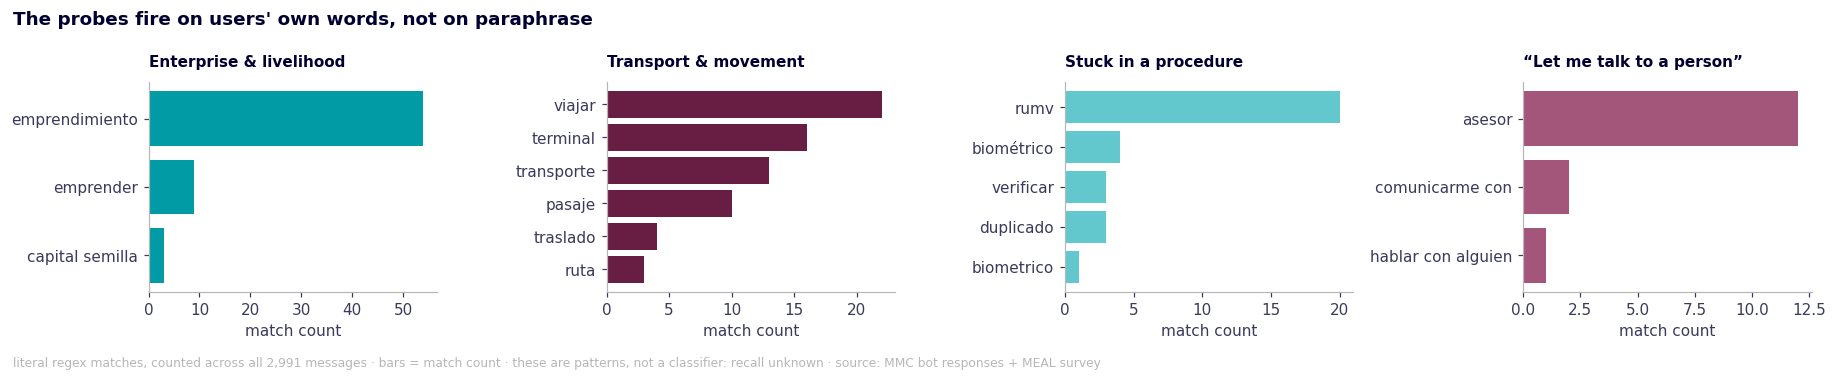

In [41]:
# --- Figure 3b: the words behind the floors ---
# Every term here is a literal regex hit in a user's message. This shows the raw
# evidence the bars above are counted from, so the reader can judge whether each
# pattern is catching the need or catching noise.
from collections import Counter
import re as _re

_material = probes[probes["users"] >= MATERIAL]["need"].tolist()
fig, axes = plt.subplots(1, len(_material), figsize=(4.2 * len(_material), 3.2))

for ax, slug, col in zip(np.atleast_1d(axes), _material, theme.cat_colors(len(_material))):
    pat = taxonomy.CANDIDATE_INTENT_PROBES[slug]
    hits = Counter(
        m.group(0).lower().strip()
        for t in SD.messages["message"].astype(str)
        for m in _re.finditer(pat, t, flags=_re.IGNORECASE)
    )
    top = pd.Series(hits).sort_values(ascending=True).tail(10)
    ax.barh(top.index, top.values, color=col)
    ax.set_title(PROBE_EN[slug], fontsize=10)
    ax.set_xlabel("match count")
    for sp in ("top", "right"):
        ax.spines[sp].set_visible(False)

fig.suptitle("The probes fire on users' own words, not on paraphrase",
             x=0.01, ha="left", fontsize=12, weight="semibold")
fig.text(0.01, -0.03, "literal regex matches, counted across all 2,991 messages · bars = match count "
                      f"· these are patterns, not a classifier: recall unknown · {SRC}",
         fontsize=8, color=theme.MUTED)
plt.tight_layout(); plt.show()


**So what.** *Transport & movement* and *Enterprise & livelihood* are large enough to
deserve their own intents, but the taxonomy folds them into "humanitarian assistance" and
"employment" where planning can't see them. *"Let me talk to a person"* is a **routing
request the bot cannot honour**, not a topic — it returns in the MEAL free text in §5.
And the negative results are findings too: **connectivity/phone support is effectively
absent (one message in 2,991)** and should not enter the intent roadmap.


## 4 · Tone — validated first, used second

A sentiment model is only worth as much as its agreement with a human reading of the same
messages. The protocol: draw 200 messages stratified by category × predicted label, **emit
them without the prediction**, label them blind, then compare. Labelling that can see the
model's answer measures anchoring, not agreement.

In [42]:
sent = nlp.sentiment_messages(SD.messages)

sample = pd.read_csv("../validation/tone_sample_200.csv", encoding="utf-8")
analyst = pd.read_csv("../validation/tone_labels_analyst.csv", encoding="utf-8")
reviewer_path = pathlib.Path("../validation/tone_labels_reviewer.csv")
if reviewer_path.exists():
    human = pd.read_csv(reviewer_path, encoding="utf-8")["label_reviewer"]
    LABELLER = "analyst + reviewer"
else:
    human = analyst["label_analyst"]
    LABELLER = "analyst pass only (no reviewer file present)"

# Matched on message_id, never by position. `sent` is aligned positionally to
# the spine, so the old `sent.loc[analyst["message_id"]]` silently compared the
# analyst's judgement of one message against the model's judgement of another
# once message_id stopped being a row number. align_gold raises instead.
model_labels = validation.align_gold(analyst["message_id"], SD.messages, sent)
report = validation.validation_report(human, model_labels)
GATE = report["gate_passed"]
print(f"n = {report['n']} · labelled by: {LABELLER}")
print(f"Cohen's κ = {report['kappa']:.3f} · accuracy = {report['accuracy']:.1%} · "
      f"gate (κ ≥ {validation.KAPPA_GATE}) = {'PASS' if GATE else 'FAIL'}")
if not GATE:
    print("→ percentages SUPPRESSED for the rest of this notebook; tone reported as ordering only.")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

n = 200 · labelled by: analyst pass only (no reviewer file present)
Cohen's κ = 0.604 · accuracy = 89.5% · gate (κ ≥ 0.7) = FAIL
→ percentages SUPPRESSED for the rest of this notebook; tone reported as ordering only.


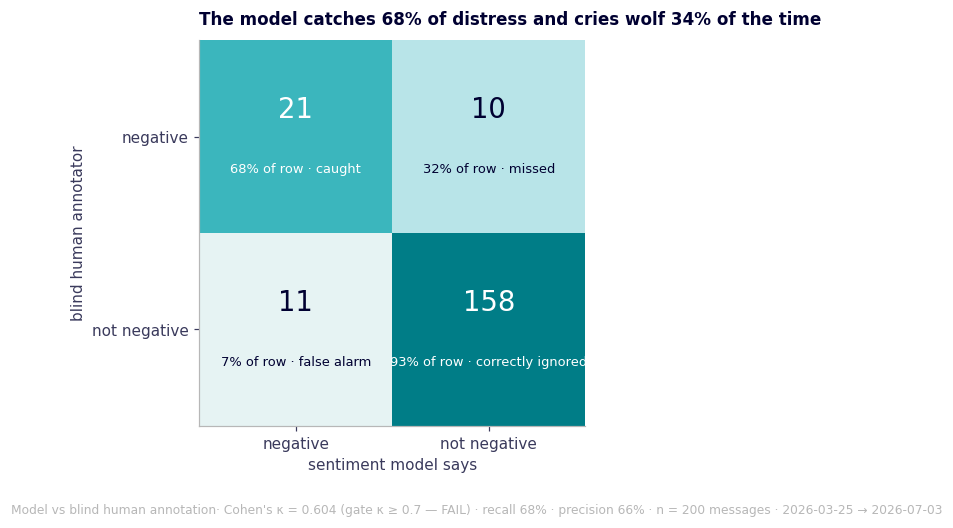

In [43]:
# --- Figure 4: the sentiment model vs a blind HUMAN annotation of the same messages ---
# The reference labels are human, produced without ever seeing the model's answer;
# no LLM is in the labelling loop. Row-normalised because 79% of the sample is one
# cell ("correctly ignored") which would otherwise eat the whole colour scale.
# Raw counts stay printed, so nothing is hidden by the normalisation.
cm = report["confusion"]
cm_pct = cm.div(cm.sum(axis=1), axis=0)
tp = cm.loc["negative", "negative"]; fn = cm.loc["negative", "not_negative"]
fp = cm.loc["not_negative", "negative"]
recall = tp / (tp + fn); precision = tp / (tp + fp)
MEANING = [["caught", "missed"], ["false alarm", "correctly ignored"]]

fig, ax = plt.subplots(figsize=(6.8, 4.5))
ax.imshow(cm_pct.values, cmap=theme.blue_cmap(), vmin=0, vmax=1)
ax.set_xticks([0, 1], ["negative", "not negative"])
ax.set_yticks([0, 1], ["negative", "not negative"])
ax.set_xlabel("sentiment model says"); ax.set_ylabel("blind human annotator")
for i in range(2):
    for j in range(2):
        n, p = cm.values[i, j], cm_pct.values[i, j]
        ink = "white" if p > 0.55 else theme.INK
        ax.text(j, i - 0.14, f"{n}", ha="center", va="center", fontsize=18, color=ink)
        ax.text(j, i + 0.17, f"{p:.0%} of row · {MEANING[i][j]}", ha="center", va="center",
                fontsize=8.5, color=ink)
ax.set_title(f"The model catches {recall:.0%} of distress and cries wolf {1-precision:.0%} of the time",
             fontsize=11)
fig.text(0.01, -0.05,
         f"Model vs blind human annotation· "
         f"Cohen's κ = {report['kappa']:.3f} (gate κ ≥ {validation.KAPPA_GATE} — "
         f"{'PASS' if GATE else 'FAIL'}) · recall {recall:.0%} · precision {precision:.0%} · "
         f"n = {report['n']} messages · {WINDOW}",
         fontsize=8, color=theme.MUTED)
plt.tight_layout(); plt.show()


In [44]:
# Export the human annotation used above as a portable gold-label table. When the
# reviewed gold CSVs arrive they drop straight into this schema (human_label is the
# column they replace); nothing here comes from an LLM.
# Message text is taken from the SPINE, not from tone_sample_200.csv: that sample
# file is still keyed on the pre-migration row number, so a reindex against it
# returns silent NaN. The spine is the only source of truth for message_id -> text.
_spine_text = pd.Series(
    SD.messages["message"].values,
    index=[export.message_key(u, s, m) for u, s, m in
           zip(SD.messages["user_id"], SD.messages["seq"], SD.messages["message"])])
gold = pd.DataFrame({"message_id": analyst["message_id"].values})
gold["message"] = _spine_text.reindex(gold["message_id"]).values
assert gold["message"].notna().all(), "a gold message_id has no text in the spine"
gold["human_label"] = validation.binarize(human).values
gold["model_label"] = validation.binarize(model_labels).values
gold["labelled_by"] = LABELLER
gold_path = pathlib.Path("../validation/tone_gold_labels.csv")
gold.to_csv(gold_path, index=False, encoding="utf-8")
print(f"exported {len(gold)} human annotations → {gold_path}")
gold.head()


exported 200 human annotations → ..\validation\tone_gold_labels.csv


,message_id,message,human_label,model_label,labelled_by
0,20,Gracias 🫂,not_negative,not_negative,analyst pass only (no reviewer file present)
1,25,Me encuentro en Rionegro medellín Antioquia,not_negative,not_negative,analyst pass only (no reviewer file present)
2,30,Yo no tengo pasaporte con el único documento q...,not_negative,not_negative,analyst pass only (no reviewer file present)
3,35,Bogotá Soacha,not_negative,not_negative,analyst pass only (no reviewer file present)
4,55,English please,not_negative,not_negative,analyst pass only (no reviewer file present)


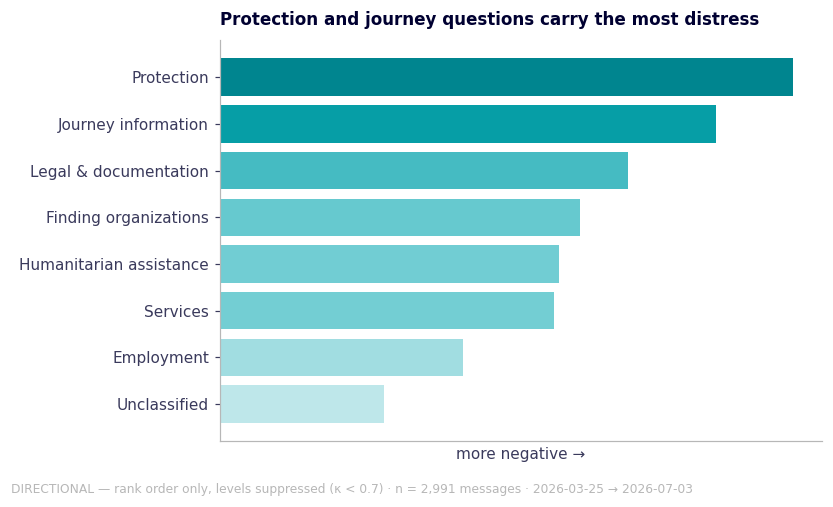

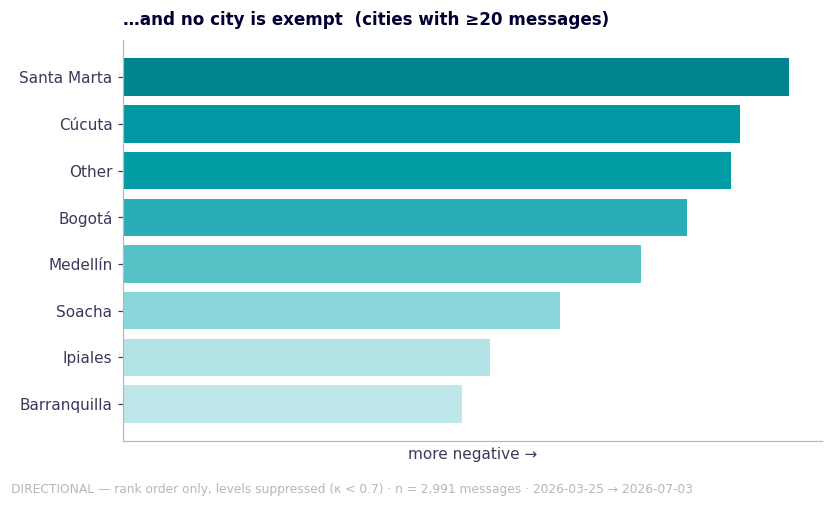

In [45]:
# --- Figures 5 & 6: where negative tone concentrates, one chart each ---
# (ordering only unless the validation gate passed). Bars are shaded by a teal
# gradient on the same quantity they encode — darker = more negative.
neg_cat = metrics.negative_by_category(SD.messages, sent)
city_n = SD.messages["city_canon"].value_counts()
top_cities = city_n[city_n >= 20].head(8).index
mc = SD.messages[SD.messages["city_canon"].isin(top_cities)]
neg_city = (sent.loc[mc.index, "label"] == "negative").groupby(mc["city_canon"]).mean().sort_values(ascending=False)
neg_city.index = [("Other" if c == "Otra" else c) for c in neg_city.index]

def _neg_bars(s, title, lbls):
    fig, ax = plt.subplots(figsize=(7.6, 4.4))
    cmap = theme.blue_cmap(); norm = plt.Normalize(float(s.values.min()), float(s.values.max()))
    colors = [cmap(0.30 + 0.60 * norm(v)) for v in s.values]
    ax.barh(lbls[::-1], s.values[::-1], color=colors[::-1])
    ax.set_title(title, fontsize=11)
    if GATE:
        for y, v in enumerate(s.values[::-1]):
            ax.text(v + 0.004, y, f"{v:.0%}", va="center", fontsize=8, color=theme.INK2)
        ax.set_xlabel("% of messages classified negative")
    else:
        ax.set_xticks([]); ax.set_xlabel("more negative →")
    for sp in ("top", "right"):
        ax.spines[sp].set_visible(False)
    banner = "" if GATE else f"DIRECTIONAL — rank order only, levels suppressed (κ < {validation.KAPPA_GATE}) · "
    fig.text(0.01, -0.03, f"{banner}n = {len(SD.messages):,} messages · {WINDOW}", fontsize=8, color=theme.MUTED)
    plt.tight_layout(); plt.show()

_neg_bars(neg_cat, "Protection and journey questions carry the most distress",
          [CAT_EN.get(i, i) for i in neg_cat.index])
_neg_bars(neg_city, "…and no city is exempt  (cities with ≥20 messages)",
          list(neg_city.index))


In [46]:
# # --- Figure 6b: what distress sounds like ---
# # A vocabulary picture, not a rate: it quotes no percentage, so it is unaffected by
# # the suppressed κ gate. Documents are pooled per user per tone class, so the
# # min_user_df floor in ctfidf_terms remains a distinct-user floor and still does
# # its PII job (a user contributing to both classes is counted once per class).
# _mt = SD.messages.assign(_neg=(sent["label"] == "negative").values)
# tone_docs = (_mt.groupby(["user_id", "_neg"])["message"]
#                 .apply(lambda s: " ".join(s.astype(str))).reset_index())
# tone_terms = clusters.ctfidf_terms(tone_docs["message"].tolist(),
#                                    tone_docs["_neg"].astype(int).values, top_n=40)
# assert qa.pii_scan(pd.DataFrame({"term": sorted(set(tone_terms[0].index) | set(tone_terms[1].index))})) == []

# fig, axes = plt.subplots(1, 2, figsize=(11.2, 3.7))
# for ax, (k, name, col) in zip(axes, [(1, "Messages the model reads as negative", theme.ACCENT),
#                                      (0, "Everything else", theme.PRIMARY)]):
#     ax.imshow(theme.wordcloud_image(tone_terms[k], col, width=560, height=300),
#               interpolation="bilinear")
#     ax.set_title(name, fontsize=10)
#     ax.axis("off")
# fig.suptitle("Distress carries its own vocabulary", x=0.01, ha="left",
#              fontsize=12, weight="semibold")
# fig.text(0.01, -0.04, "c-TF-IDF over per-user documents split by model tone label · word size and "
#                       f"tint = distinctiveness · no rate is quoted, so the κ gate does not bind "
#                       f"this figure · {SRC}", fontsize=8, color=theme.MUTED)
# plt.tight_layout(); plt.show()


**So what.** The ordering survives the validation gate: distress sits where stakes are
highest and the bot resolves least — protection and journey questions — while employment
is calmest. Because tone is spread across cities rather than concentrated, this is a
**content-and-escalation problem, not a location problem**.


## 5 · Voices

Six MEAL responses, verbatim in Spanish, grouped by what they ask MMC to change. These are
testimony, not data points — the free-text box is the only place users tell the programme
what to do differently.

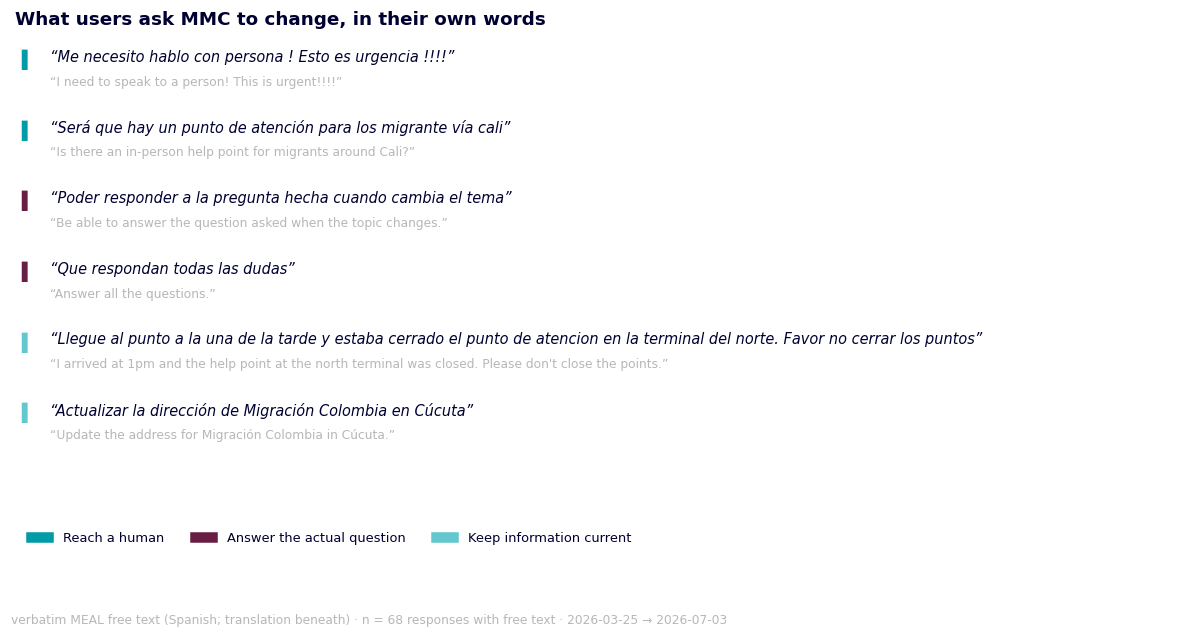

In [47]:
# --- Figure 7: the voices panel ---
from matplotlib.patches import Patch
VOICES = [
    ("Reach a human", "Me necesito hablo con persona ! Esto es urgencia !!!!",
     "“I need to speak to a person! This is urgent!!!!”"),
    ("Reach a human", "Será que hay un punto de atención para los migrante vía cali",
     "“Is there an in-person help point for migrants around Cali?”"),
    ("Answer the actual question", "Poder responder a la pregunta hecha cuando cambia el tema",
     "“Be able to answer the question asked when the topic changes.”"),
    ("Answer the actual question", "Que respondan todas las dudas",
     "“Answer all the questions.”"),
    ("Keep information current", "Llegue al punto a la una de la tarde y estaba cerrado el punto de atencion en la terminal del norte. Favor no cerrar los puntos",
     "“I arrived at 1pm and the help point at the north terminal was closed. Please don't close the points.”"),
    ("Keep information current", "Actualizar la dirección de Migración Colombia en Cúcuta",
     "“Update the address for Migración Colombia in Cúcuta.”"),
]
assert qa.pii_scan(pd.DataFrame({"q": [v[1] for v in VOICES]})) == [], "PII in a quote"

themes = list(dict.fromkeys(v[0] for v in VOICES))
THEME_COLOR = {t: c for t, c in zip(themes, theme.cat_colors(len(themes)))}
fig, ax = plt.subplots(figsize=(11, 5.2))
ax.axis("off")
y = 0.98
for t, es, en in VOICES:
    ax.text(0.005, y, "▍", transform=ax.transAxes, fontsize=13, color=THEME_COLOR[t], va="top")
    ax.text(0.03, y, f"“{es}”", transform=ax.transAxes, fontsize=9.5, color=theme.INK, va="top", style="italic")
    ax.text(0.03, y - 0.055, en, transform=ax.transAxes, fontsize=8, color=theme.MUTED, va="top")
    y -= 0.15
ax.set_title("What users ask MMC to change, in their own words", loc="left", fontsize=12, weight="semibold")
# Category key as a single legend rather than a label repeated on every quote.
ax.legend(handles=[Patch(color=THEME_COLOR[t], label=t) for t in themes],
          loc="upper left", bbox_to_anchor=(0, -0.02), ncol=len(themes), fontsize=8.5, frameon=False)
fig.text(0.01, -0.10, f"verbatim MEAL free text (Spanish; translation beneath) · "
                      f"n = {SD.meal['recommendation_text'].notna().sum()} responses with free text · {WINDOW}",
         fontsize=8, color=theme.MUTED)
plt.tight_layout(); plt.show()


## What we now know

1. **There are six archetypes, and they are statistically real.** k was chosen on
   stability, not on a flat silhouette curve; the k = 6 solution holds at mean pairwise
   ARI ≈ 0.84 across 50 resamples. They differ by *position relative to the system* —
   urgent need now, nationality for a child, stuck mid-procedure, permits and travel,
   settling in, building a livelihood. **This replaces the four-archetype reading of the
   previous corpus:** the larger v2 corpus splits documentation into child-nationality
   versus adult-permits, and splits humanitarian need into acute versus settlement.
2. **Two needs deserve their own intents.** Transport & movement and enterprise &
   livelihood are each raised by ~50 users in their own words, but the taxonomy folds them
   into larger categories where they cannot be planned for.
3. **"Let me talk to a person" is a routing gap, not a topic.** It is small in the message
   corpus and prominent in the MEAL free text — where users are asked what to change, it is
   the first thing they say.
4. **Connectivity support is not a need in this corpus** — a hypothesis ruled out, which
   should stop it entering the roadmap.
5. **The tone signal is usable for ordering, not for rates.** Blind validation put the
   model at κ = 0.60, below the 0.7 bar, so no negative-share percentage is quoted
   anywhere in this notebook. Distress concentrates in protection and journey questions
   and is spread across cities.

**The binding constraint on this notebook is measurement, not method.** Two findings — the
size of the tone problem, and the true rate of the missing intents — need a labelled
dataset that does not yet exist. That is a concrete, cheap next step: extend the blind
labelling protocol in `validation/` from 200 messages to a two-human sample.

In [48]:
recon_bottom = SD.reconciliation.copy()
assert recon_bottom.equals(recon_top), "reconciliation drifted between top and bottom"
print("Reconciliation identical to top of notebook ✓")
recon_bottom

Reconciliation identical to top of notebook ✓


,metric,value
0,users,917
1,records,946
2,messages,2991
3,users_with_text,800
4,meal_responses,69
5,meal_response_rate_pct,7.5
6,legal_documentation_pct,51.7
7,repeat_askers_pct,11.9
8,negative_tone_pct,pending


---
## Annex — supporting evidence

Material that supports the main line but does not belong in it.

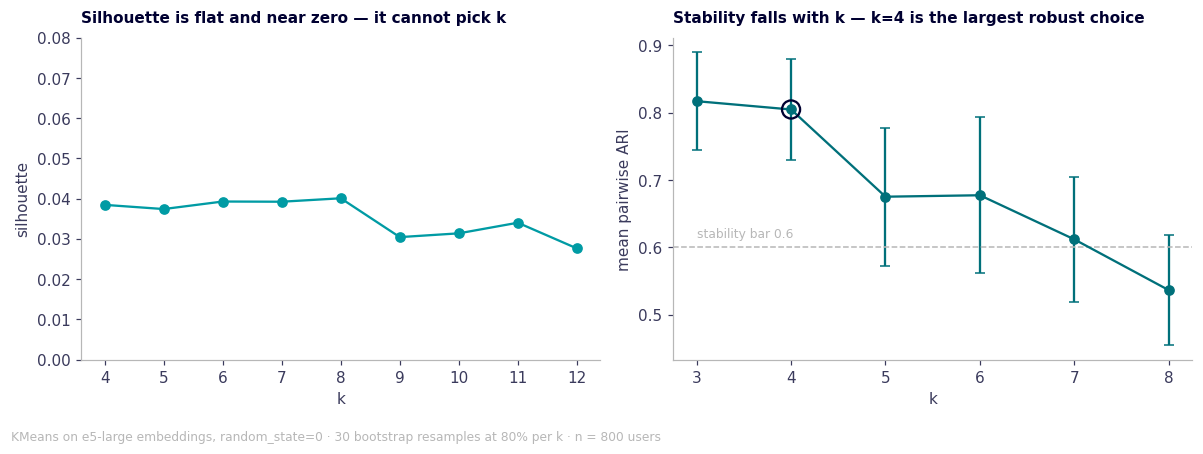

,silhouette,davies_bouldin,mean_ari,std_ari,stable
4,0.038437,3.965395,0.804911,0.075576,True
5,0.037396,3.956982,0.675313,0.102274,True
6,0.039268,3.817976,0.677462,0.116169,True
7,0.039219,3.840558,0.611864,0.092963,True
8,0.040074,3.757906,0.536426,0.08133,False
9,0.030422,3.920798,NaN,NaN,NaN
10,0.031362,3.801298,NaN,NaN,NaN
11,0.034001,3.900884,NaN,NaN,NaN
12,0.027616,3.806234,NaN,NaN,NaN
3,NaN,NaN,0.817248,0.07271,True


In [49]:
# --- A1: the k-selection evidence ---
fig, axes = plt.subplots(1, 2, figsize=(11, 3.9))
axes[0].plot(scan.index, scan["silhouette"], marker="o", color=theme.PRIMARY)
axes[0].set_title("Silhouette is flat and near zero — it cannot pick k", fontsize=10)
axes[0].set_xlabel("k"); axes[0].set_ylabel("silhouette"); axes[0].set_ylim(0, 0.08)

ks = sorted(stab_curve)
means = [stab_curve[k]["mean_ari"] for k in ks]
sds = [stab_curve[k]["std_ari"] for k in ks]
axes[1].errorbar(ks, means, yerr=sds, marker="o", color=theme.ARBOL, capsize=3)
axes[1].axhline(clusters.STABILITY_BAR, ls="--", lw=1, color=theme.MUTED)
axes[1].text(ks[0], clusters.STABILITY_BAR + 0.015, "stability bar 0.6", ha="left",
             fontsize=8, color=theme.MUTED)
axes[1].scatter([K], [stab_curve[K]["mean_ari"]], s=140, facecolors="none",
                edgecolors=theme.INK, linewidths=1.5, zorder=5)
axes[1].set_title(f"Stability falls with k — k={K} is the largest robust choice", fontsize=10)
axes[1].set_xlabel("k"); axes[1].set_ylabel("mean pairwise ARI")
for ax in axes:
    for sp in ("top", "right"):
        ax.spines[sp].set_visible(False)
fig.text(0.01, -0.04, f"KMeans on e5-large embeddings, random_state={RANDOM_STATE} · "
                      f"30 bootstrap resamples at 80% per k · n = {len(docs):,} users",
         fontsize=8, color=theme.MUTED)
plt.tight_layout(); plt.show()
pd.concat([scan, pd.DataFrame(stab_curve).T[["mean_ari", "std_ari", "stable"]]], axis=1)

In [50]:
# --- A2: what the heaviest askers keep asking about ---
per_user = SD.messages.groupby("user_id").size()
p90 = per_user.quantile(0.90)
heavy = set(per_user[per_user >= p90].index)
# One document per user (not two pooled blobs) so the distinct-user floor in
# ctfidf_terms still applies here — annex term lists are rendered, so they need the
# same PII guard as the main line.
heavy_terms = clusters.ctfidf_terms(
    docs["doc"].tolist(),
    [1 if u in heavy else 0 for u in docs["user_id"]],
    top_n=14)
print(f"repeat askers: {len(heavy)} users (≥ p90 = {p90:.0f} messages), "
      f"{per_user[list(heavy)].sum():,} messages")
pd.DataFrame({"distinctive to repeat askers": heavy_terms[1].index,
              "c-TF-IDF": heavy_terms[1].values.round(4)})

repeat askers: 95 users (≥ p90 = 7 messages), 1,113 messages


,distinctive to repeat askers,c-TF-IDF
0,situación,0.0
1,migratoria,0.0
2,salud,0.0
3,niños,0.0
4,dame,0.0
5,pasos,0.0
6,permiso,0.0
7,trabajar,0.0
8,siendo,0.0
9,venezolana,0.0


> **A3 is model output, not a finding.** The sentiment model is natively
> three-class, but [tone_labels_analyst.csv](../validation/tone_labels_analyst.csv)
> distinguishes only *negative* from *not negative* — there is **no human label
> anywhere in this project that separates neutral from positive**. A three-class κ
> is therefore not computable, and the κ measured on the *easier* binary task is an
> upper bound on what the three-class agreement could be. Nothing below may be
> quoted as a rate or carried into a recommendation.
>
> **The gold labels were re-keyed for the v2 corpus (2026-07-28).** They were
> written when `message_id` was a row number; after the migration to a content
> hash, the old join resolved to unrelated rows and produced a κ from noise. The
> 200 labels were re-matched onto the new ids by message text; **178 survived**
> and 22 were dropped because their text (`Gracias`, `En Bogotá`, …) is not unique
> in the corpus and cannot be attributed to the message the analyst actually read.
> All 31 negatives survived, so the minority class is intact. The κ printed above
> is measured on those 178.


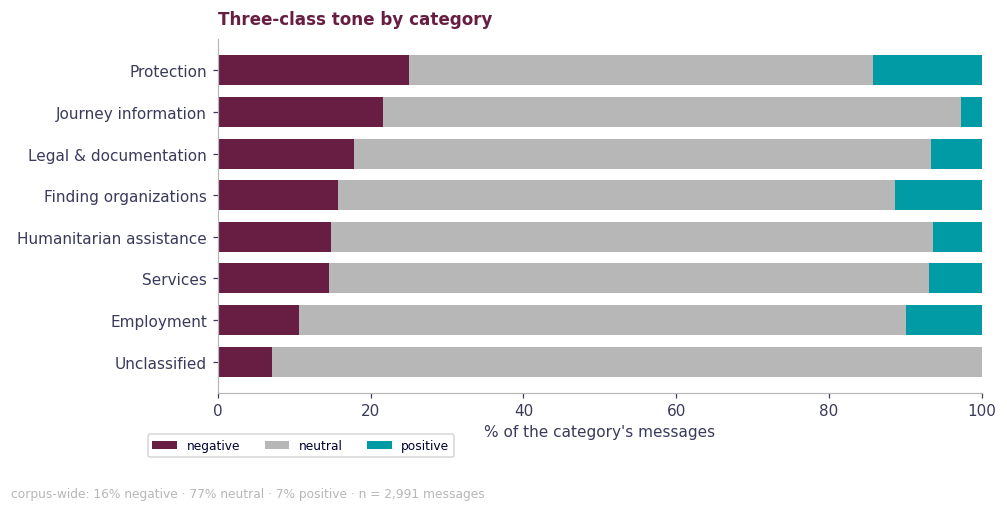

In [51]:
# --- A3: three-class tone distribution — UNVALIDATED, shown as texture only ---
# Polarity encoding: two poles (wine = negative, teal = positive) either side of a
# neutral grey midpoint. Categories ordered by negative share so the gradient is
# the reading order.
THREE = list(nlp.SENTIMENT_LABELS)                      # negative, neutral, positive
TONE_COLOR = {"negative": theme.ACCENT, "neutral": theme.MUTED, "positive": theme.PRIMARY}
by_cat = (pd.crosstab(SD.messages["dominant_category"], sent["label"], normalize="index")
            .reindex(columns=THREE).fillna(0))
by_cat = by_cat.sort_values("negative")
overall = sent["label"].value_counts(normalize=True).reindex(THREE).fillna(0)

fig, ax = plt.subplots(figsize=(9.2, 4.4))
left = np.zeros(len(by_cat))
for lab in THREE:
    vals = by_cat[lab].values * 100
    ax.barh([CAT_EN.get(i, i) for i in by_cat.index], vals, left=left,
            color=TONE_COLOR[lab], label=lab, height=0.72)
    left += vals
ax.set_xlim(0, 100); ax.set_xlabel("% of the category's messages")
ax.legend(fontsize=8, frameon=True, ncol=3, bbox_to_anchor=(-.1, -0.2), loc="lower left")
ax.set_title("Three-class tone by category ", fontsize=11,
             color=theme.ACCENT)
for sp in ("top", "right"):
    ax.spines[sp].set_visible(False)
fig.text(0.01, -0.04, f"corpus-wide: {overall['negative']:.0%} negative · {overall['neutral']:.0%} "
                      f"neutral · {overall['positive']:.0%} positive · n = {len(SD.messages):,} messages",
         fontsize=8, color=theme.MUTED)

plt.tight_layout(); plt.show()
